# Asymmetry Analysis
This notebook loads spectra from the generated Asym_* folders, computes regional metrics, and displays diagnostics for each asymmetry level.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

In [2]:
regions = [
    (0.80, 1),   # Rayleigh + optical continuum / H− slope
    (1, 1.16),   # continuum (reference baseline)
    (1.16, 1.30),   # weak H2O + continuum transition
    (1.30, 1.50),   # STRONG H2O band (main signal)
    (1.50, 1.70),   # H2O wing / opacity plateau
    (1.70, 1.95),   # second H2O band
    (1.95, 2.20)    # deep IR tail (temperature + opacity)
]
work_dir = os.getcwd()
def load_phase_data(folder):
    base = os.path.join(work_dir, folder)
    def load_one(phase):
        path = os.path.join(base, f"{phase}.txt")
        data = np.loadtxt(path)
        data = data[~np.isnan(data).any(axis=1)]
        return data
    return (load_one("ingress"), load_one("mid"), load_one("egress"))
def analyze_folder(folder):
    ing, mid, egr = load_phase_data(folder)
    λ = ing[:, 0]
    transit_ing = ing[:, -1]
    transit_mid = mid[:, -1]
    transit_egr = egr[:, -1]
    ni = ing[:, 2]
    nm = mid[:, 2]
    ne = egr[:, 2]
    rng = np.random.default_rng(42)
    N_MC = 1000
    regional_rows = []
    mc_results = {r: {'σ_det': [], '|I−E|': [], 'Z_D': [], 'ρ': []} for r in range(len(regions))}
    for k in range(N_MC):
        mc_ing = transit_ing + rng.normal(0.0, ni)
        mc_mid = transit_mid + rng.normal(0.0, nm)
        mc_egr = transit_egr + rng.normal(0.0, ne)
        for r_idx, (r1, r2) in enumerate(regions):
            mask = (λ >= r1) & (λ <= r2)
            fi_reg = mc_ing[mask]
            fe_reg = mc_egr[mask]
            ni_reg = ni[mask]
            ne_reg = ne[mask]
            spec_diff = fi_reg - fe_reg
            σ_comb = np.sqrt(ni_reg**2 + ne_reg**2)
            if len(σ_comb) > 0 and np.any(σ_comb > 0):
                σ_det = np.mean(spec_diff / σ_comb)
            else:
                σ_det = np.nan
            mc_results[r_idx]['σ_det'].append(σ_det)
            mc_results[r_idx]['|I−E|'].append(np.mean(np.abs(spec_diff)) if spec_diff.size else np.nan)
            if np.std(mc_mid[mask]) > 0:
                Z_D = (np.max(mc_mid[mask]) - np.min(mc_mid[mask])) / np.std(mc_mid[mask])
                mc_results[r_idx]['Z_D'].append(Z_D)
            if len(fi_reg) > 1 and np.std(fi_reg) > 0 and np.std(fe_reg) > 0:
                ρ = np.corrcoef(fi_reg, fe_reg)[0, 1]
                mc_results[r_idx]['ρ'].append(ρ)
    for r_idx, (r1, r2) in enumerate(regions):
        σ_det_vals = np.array(mc_results[r_idx]['σ_det'])
        diff_vals = np.array(mc_results[r_idx]['|I−E|'])
        z_vals = np.array(mc_results[r_idx]['Z_D']) if mc_results[r_idx]['Z_D'] else np.array([np.nan])
        ρ_vals = np.array(mc_results[r_idx]['ρ']) if mc_results[r_idx]['ρ'] else np.array([np.nan])
        regional_rows.append({
            'Region': f"{r1}-{r2}",
            'σ_det': np.mean(σ_det_vals),
            'σ_det_err': np.std(σ_det_vals),
            '|I−E|': np.mean(diff_vals),
            '|I−E|_err': np.std(diff_vals),
            'Z_D': np.nanmean(z_vals),
            'ρ': np.nanmean(ρ_vals)
        })
    global_rms = []
    global_E = []
    for k in range(N_MC):
        mc_ing = transit_ing + rng.normal(0.0, ni)
        mc_egr = transit_egr + rng.normal(0.0, ne)
        spec_diff = mc_ing - mc_egr
        abs_diff = np.abs(spec_diff)
        rms = np.sqrt(np.mean(abs_diff**2))
        global_rms.append(rms)
        μ_i = np.mean(mc_ing)
        μ_e = np.mean(mc_egr)
        σ_i = np.std(mc_ing)
        σ_e = np.std(mc_egr)
        if (σ_i**2 + σ_e**2) > 0:
            E = (μ_i - μ_e) / np.sqrt((σ_i**2 + σ_e**2) / 2)
        else:
            E = np.nan
        global_E.append(E)
    return pd.DataFrame(regional_rows), pd.DataFrame([{
        'Case': folder,
        'RMS': np.mean(global_rms),
        'RMS_err': np.std(global_rms),
        'E': np.mean(global_E),
        'E_err': np.std(global_E)
    }])

In [9]:
synthetic_folders = sorted(glob.glob("Asym_*"))
literature_folders = ["Literature_Alderson_Symmetric", "Literature_Alderson_Mild_Asymmetry"]
folders = synthetic_folders + [f for f in literature_folders if os.path.isdir(f)]
print("Detected folders:")
for f in folders:
    print("  ", f)
results = []
for folder in folders:
    print("Processing:", folder)
    df_reg, df_global = analyze_folder(folder)
    display(df_reg)
    display(df_global)
    results.append(df_global.iloc[0])
results_df = pd.DataFrame(results)
print("\nSummary of global metrics:")
display(results_df)

Detected folders:
   Asym_0.1
   Asym_0.2
   Asym_0.3
   Asym_0.4
   Asym_0.5
   Asym_0.6
   Asym_0.7
   Asym_0.8
   Asym_0.9
   Asym_1.0
   Literature_Alderson_Symmetric
   Literature_Alderson_Mild_Asymmetry
Processing: Asym_0.1


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,0.588240,0.037171,0.000494,0.000014,5.937483,0.855102
1,1-1.16,0.531050,0.047766,0.000500,0.000018,4.349276,0.945652
2,1.16-1.3,0.487873,0.054341,0.000524,0.000021,6.195556,0.589966
3,1.3-1.5,0.279769,0.049066,0.000419,0.000017,3.296310,0.995065
4,1.5-1.7,0.380590,0.052796,0.000581,0.000023,5.816262,0.271533
5,1.7-1.95,0.240212,0.049734,0.000473,0.000018,3.142598,0.995266
6,1.95-2.2,0.259103,0.052862,0.000621,0.000026,4.021079,0.976570


,Case,RMS,RMS_err,E,E_err
0,Asym_0.1,0.000648,0.000008,0.056905,0.002552


Processing: Asym_0.2


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,1.127052,0.037171,0.000668,0.000017,5.937483,0.854460
1,1-1.16,1.017625,0.047766,0.000651,0.000021,4.349276,0.945447
2,1.16-1.3,0.932892,0.054341,0.000660,0.000025,6.195556,0.589518
3,1.3-1.5,0.530872,0.049066,0.000468,0.000018,3.296310,0.995024
4,1.5-1.7,0.725122,0.052796,0.000679,0.000025,5.816262,0.269446
5,1.7-1.95,0.453732,0.049734,0.000517,0.000020,3.142598,0.995260
6,1.95-2.2,0.488774,0.052862,0.000674,0.000027,4.021079,0.976554


...

Processing: Literature_Alderson_Mild_Asymmetry


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,1.004078,0.037171,0.000621,0.000016,5.937483,0.853965
1,1-1.16,0.908036,0.047766,0.000611,0.000021,4.349276,0.945246
2,1.16-1.3,0.830199,0.054341,0.000622,0.000024,6.195556,0.588621
3,1.3-1.5,0.456266,0.049066,0.000452,0.000018,3.296310,0.995009
4,1.5-1.7,0.636440,0.052796,0.000649,0.000025,5.816262,0.269082
5,1.7-1.95,0.390284,0.049734,0.000502,0.000019,3.142598,0.995244
6,1.95-2.2,0.414076,0.052862,0.000654,0.000027,4.021079,0.976465


,Case,RMS,RMS_err,E,E_err
0,Literature_Alderson_Mild_Asymmetry,0.000736,0.000009,0.095605,0.002557



Summary of global metrics:


,Case,RMS,RMS_err,E,E_err
0,Asym_0.1,0.000648,0.000008,0.056905,0.002552
0,Asym_0.2,0.000771,0.000009,0.108383,0.002552
0,Asym_0.3,0.000931,0.000010,0.158330,0.002553
0,Asym_0.4,0.001112,0.000010,0.207603,0.002555
0,Asym_0.5,0.001305,0.000010,0.256493,0.002558
0,Asym_0.6,0.001506,0.000010,0.305124,0.002561
0,Asym_0.7,0.001711,0.000011,0.353551,0.002565
0,Asym_0.8,0.001919,0.000011,0.401802,0.002569
0,Asym_0.9,0.002130,0.000011,0.449888,0.002574
0,Asym_1.0,0.002343,0.000011,1.881206,0.011812


ValueError: 'x' and 'y' must have the same size

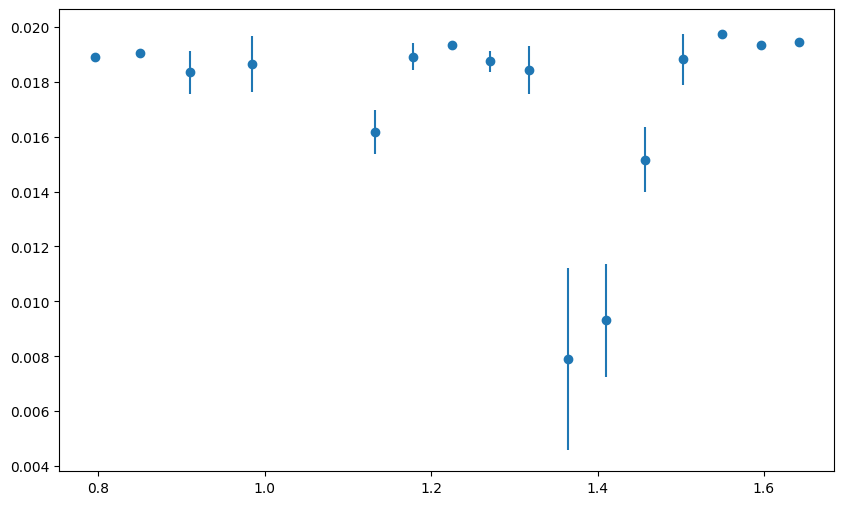

In [12]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
# 1. Load PSG spectrum
wave_syn, noise_syn, flux_syn = np.loadtxt(
    "../Literature_Alderson_Symmetric/mid.txt",
    comments="#", usecols=(0, 2, 5), unpack=True)
# 2. Convert to transit depth
psg_level = np.nanmedian(flux_syn)
if psg_level > 0.5:
    depth_syn = 1.0 - flux_syn
else:
    depth_syn = flux_syn
# 3. Sort
idx = np.argsort(wave_syn)
wave_syn = wave_syn[idx]
depth_syn = depth_syn[idx]
# 4. Instrument spectral resolution model (HST/WFC3 G141)
# R ~ 70 at 1.4 μm → Δλ ~ 0.02 μm
fwhm = 0.02
σ = fwhm / (2.355)
# Smooth PSG to instrument resolution
depth_conv = gaussian_filter1d(depth_syn, σ / np.mean(np.diff(wave_syn)))
# 5. Define WFC3 bins (from literature file)
wave_lit, δ_lit = np.loadtxt("../Literature_Alderson_Symmetric/WASP-17b_transmission_Sing2016.txt",
    comments="#", usecols=(0, 1), unpack=True)
# 6. Bin convolved PSG into WFC3 bins
depth_binned = []
err_binned = []
for wl, dw in zip(wave_lit, δ_lit):
    m = (wave_syn >= wl - dw) & (wave_syn <= wl + dw)
    if np.any(m):
        depth_binned.append(np.mean(depth_conv[m]))
        err_binned.append(np.std(depth_conv[m]))
    else:
        depth_binned.append(np.nan)
        err_binned.append(np.nan)
depth_binned = np.array(depth_binned)
err_binned = np.array(err_binned)
# 7. Plot comparison (true forward model)
plt.figure(figsize=(10, 6))
lit_data = np.loadtxt("../Literature_Alderson_Symmetric/WASP-17b_transmission_Sing2016.txt", comments="#",
    usecols=(2,), unpack=True)[0]
plt.errorbar(wave_lit, depth_binned, yerr=err_binned, fmt="o", label="PSG (HST/WFC3-convolved)")
plt.errorbar(wave_lit, lit_data, fmt="o", label="Literature (Sing et al. 2016)")
plt.xlabel("λ (μm)")
plt.ylabel(r"$(R_p/R_s)^2$")
plt.title("PSG → HST/WFC3 forward model comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [32]:
print("mean PSG =", np.mean(transit_syn))
print("mean literature =", np.mean(depth_lit))

mean PSG = 0.01691403470355731
mean literature = 0.014935507999999998


In [33]:
scale = np.mean(depth_lit) / np.mean(transit_syn)
print(scale)

0.883024556929566


In [35]:
print(transit_syn.min())
print(transit_syn.max())
imin = np.argmin(transit_syn)
imax = np.argmax(transit_syn)
print("MIN:")
print(wave_syn[imin], transit_syn[imin])
print("MAX:")
print(wave_syn[imax], transit_syn[imax])

0.00196018
0.019885
MIN:
1.872076217 0.00196018
MAX:
1.549728237 0.019885


In [36]:
mask = (wave_syn > 1.30) & (wave_syn < 1.50)
print(wave_syn[mask][np.argmin(transit_syn[mask])], transit_syn[mask].min())

1.362200054 0.00328134


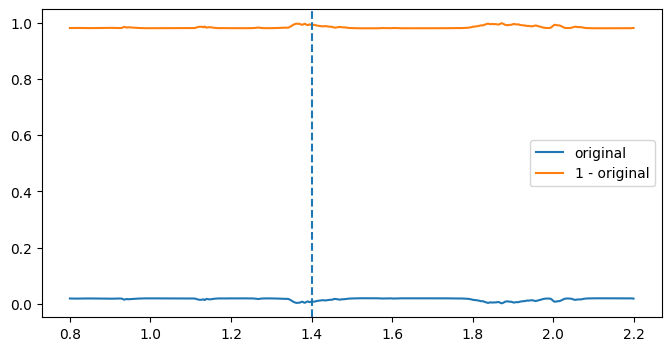

In [38]:
plt.figure(figsize=(8,4))

plt.plot(wave_syn, transit_syn, label="original")
plt.plot(wave_syn, 1.0 - transit_syn, label="1 - original")

plt.axvline(1.4, ls="--")
plt.legend()
plt.show()

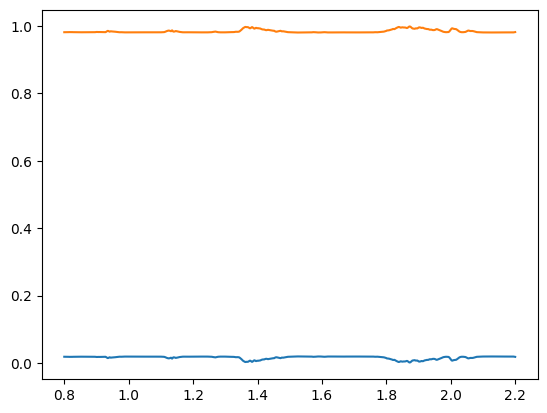

In [5]:
plt.plot(wave_syn, transit_syn)
plt.plot(wave_syn, 1 - transit_syn)